**Install the PyTorch & YOLO Libraries**

In [3]:
pip install ultralytics torch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.6 MB/s eta 0:00:00


**Import the dataset from roboflow**

In [4]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="HlfsiXEILIF0NscymTeh")
project = rf.workspace("roboflow-universe-projects").project("construction-site-safety")
version = project.version(30)
dataset = version.download("yolov8")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 91.0 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Construction-Site-Safety-30 in yolov8:: 100%|██████████| 1446/1446 [00:00<00:00, 1730.96it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


**Train the YOLOv8 Model**

In [5]:
from ultralytics import YOLO

# 1. Load the pre-trained YOLOv8 'nano' model (the fastest version)
model = YOLO('yolov8n.pt')

# 2. Train the model!
# We dynamically pass the location of the data.yaml file from your Roboflow download
results = model.train(data=f"{dataset.location}/data.yaml", epochs=25, imgsz=640)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Construction-Site-Safety-30/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience

**Download Your AI Brain**

In [6]:
from google.colab import files
files.download('/content/runs/detect/train/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Test the AI**


image 1/114 /content/Construction-Site-Safety-30/valid/images/-1079-_png_jpg.rf.77459a818bed5a44927d46bdb976c661.jpg: 640x640 1 Excavator, 1 Hardhat, 1 Person, 302.3ms
image 2/114 /content/Construction-Site-Safety-30/valid/images/-1429-_png_jpg.rf.d88afaebfda9ebdd21b532caeceb70fd.jpg: 640x640 1 Hardhat, 2 NO-Safety Vests, 3 Persons, 423.9ms
image 3/114 /content/Construction-Site-Safety-30/valid/images/-1969-_png_jpg.rf.c383b0a9a12f96b66d8089f4b4cb8b5c.jpg: 640x640 1 Hardhat, 2 Persons, 280.4ms
image 4/114 /content/Construction-Site-Safety-30/valid/images/-1989-_png_jpg.rf.3f49422a352c92297c67d4c2fd51432d.jpg: 640x640 3 Hardhats, 3 NO-Masks, 4 NO-Safety Vests, 4 Persons, 211.9ms
image 5/114 /content/Construction-Site-Safety-30/valid/images/-211-_png_jpg.rf.63b7213fc11cd2d7db6d8fff0e490d2c.jpg: 640x640 (no detections), 204.5ms
image 6/114 /content/Construction-Site-Safety-30/valid/images/-3154-_png_jpg.rf.66d16f52f6fa0f4111cb731d9078468d.jpg: 640x640 1 Hardhat, 1 NO-Mask, 2 NO-Safety Ve

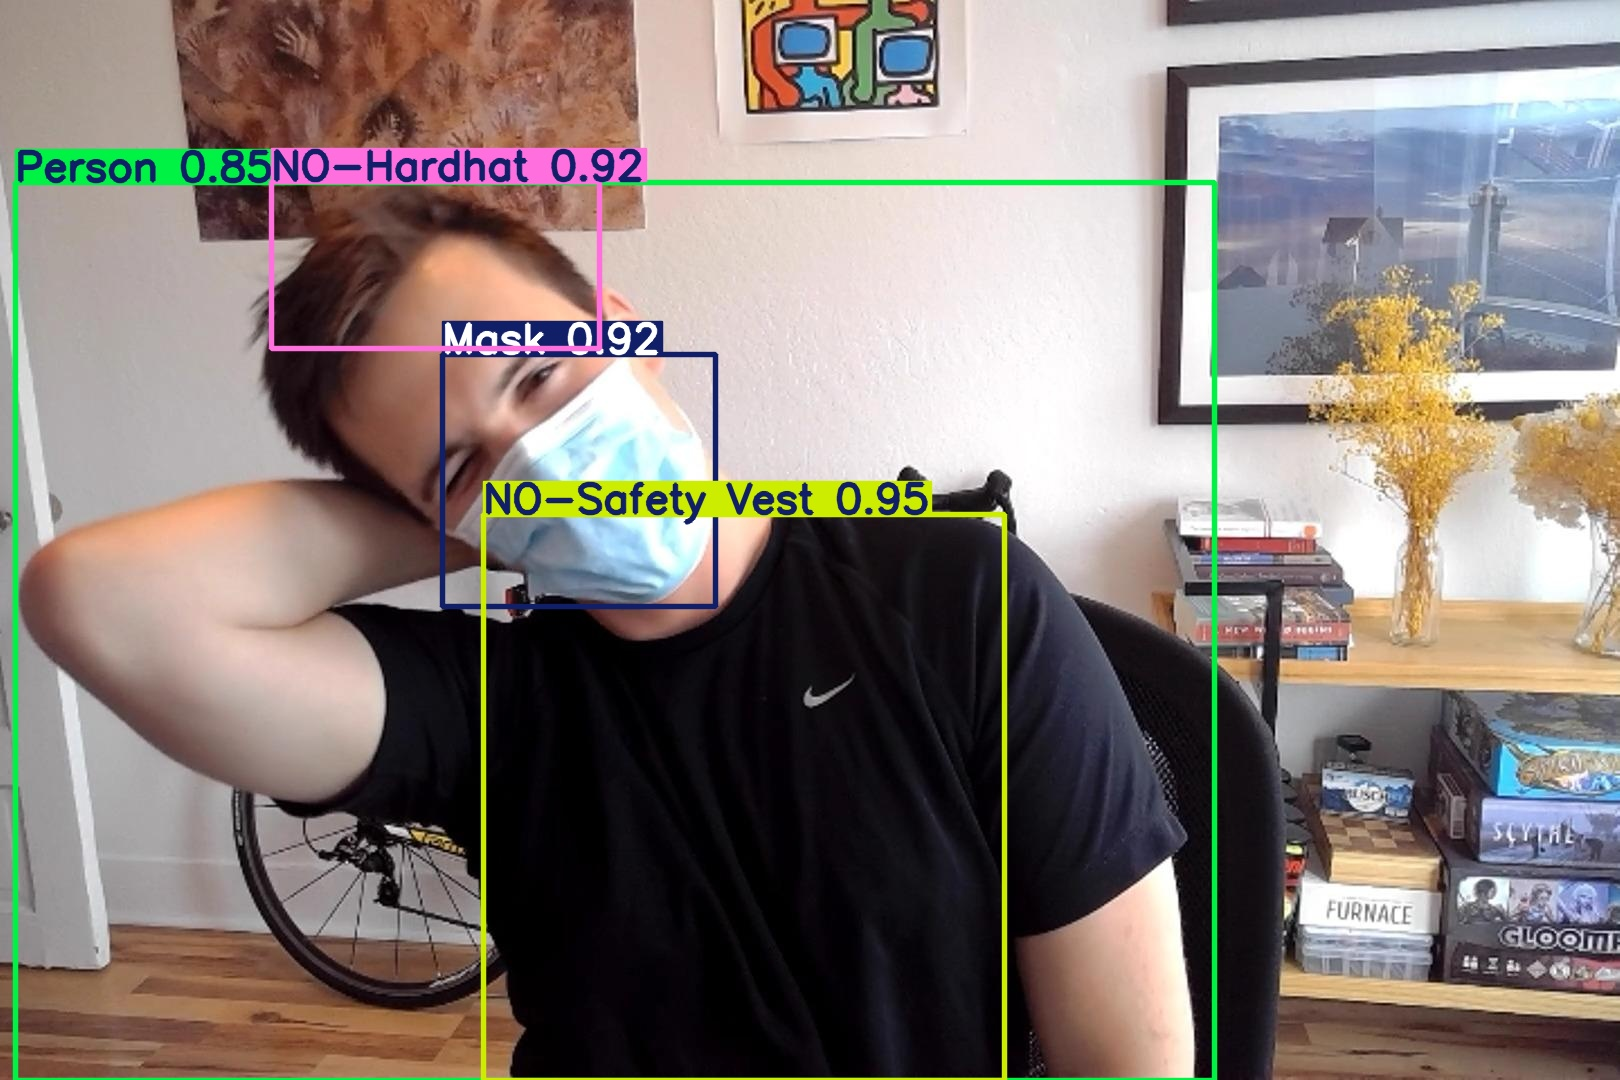

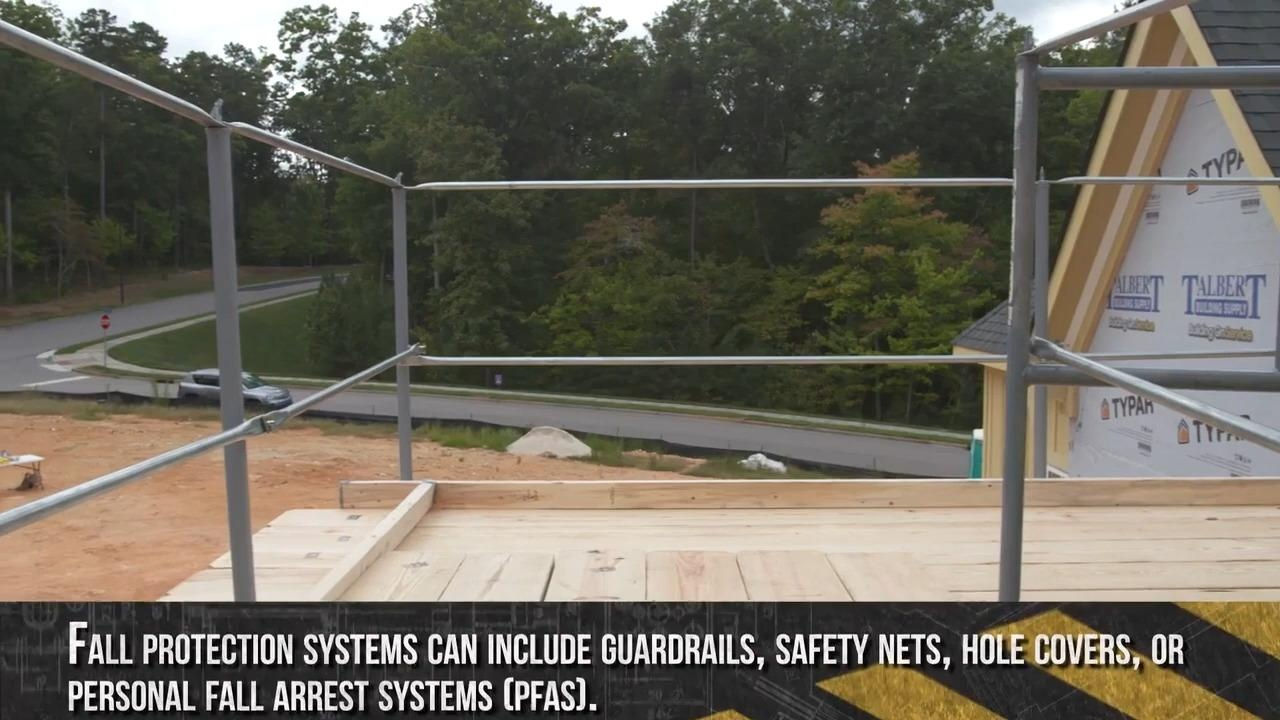

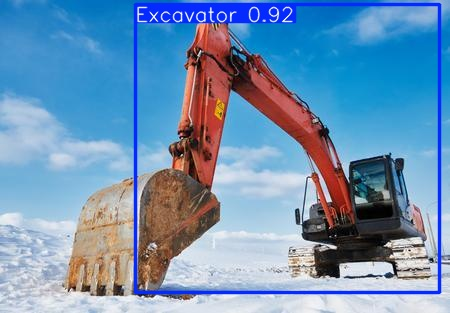

In [7]:
from ultralytics import YOLO
import glob
from IPython.display import Image, display

# 1. Load YOUR newly trained model
my_model = YOLO('/content/runs/detect/train/weights/best.pt')

# 2. Run prediction on the validation images (saving the results)
my_model.predict(source=f"{dataset.location}/valid/images", save=True, conf=0.5)

# 3. Display 3 of the newly predicted images right here in Colab!
predicted_images = glob.glob('/content/runs/detect/predict/*.jpg')
for img in predicted_images[:3]:
    display(Image(filename=img))